# Evaluation — RAGAS
## CAS NLP 2025/26 University of Bern — Final Project 

Evaluation of the RAG pipeline using RAGAS metrics:
- **Faithfulness**: are claims in the answer supported by the retrieved chunks?
- **Answer Relevance**: does the answer address the question?
- **Context Precision**: are the retrieved chunks relevant to the question?

Local evaluation: Ollama qwen3:8b as judge LLM.
Production evaluation: gpt-oss-120b via UniBE GPUStack.

## 1. Environment Setup

In [2]:
import json
import os
import pathlib
import pandas as pd
import chromadb
import requests
from sentence_transformers import SentenceTransformer

os.chdir('/Users/Olga 1/Documents/01_AD_ASTRA/0102_LANGUAGES/CAS_NLP_2025/final_project')

# Load embedding model
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Load ChromaDB index
chroma_client = chromadb.PersistentClient(path="data/chroma")
collection = chroma_client.get_collection("jugend_medien")

# Load chunks dataframe
with open("data/chunks/chunks.json", encoding="utf-8") as f:
    records = json.load(f)
df = pd.DataFrame(records)

# Load source titles
exec(open("notebooks/source_titles.py").read()) if pathlib.Path("notebooks/source_titles.py").exists() else None

print(f"Collection: {collection.count()} chunks")
print(f"Chunks dataframe: {len(df)} rows")
print("Ready.")

Collection: 375 chunks
Chunks dataframe: 375 rows
Ready.


## 1.1. Environment Patch — RAGAS Compatibility Fix

In [4]:
# Patch ragas/llms/base.py to fix import incompatibility
# ragas 0.4.3 references langchain_community.chat_models.vertexai (removed in 0.4.x)
# Fix: redirect to langchain_google_vertexai

import pathlib

base_path = pathlib.Path("venv_rag/lib/python3.12/site-packages/ragas/llms/base.py")

content = base_path.read_text()

content = content.replace(
    "from langchain_community.chat_models.vertexai import ChatVertexAI",
    "from langchain_google_vertexai import ChatVertexAI"
)
content = content.replace(
    "from langchain_community.llms import VertexAI",
    "from langchain_google_vertexai import VertexAI"
)

base_path.write_text(content)
print("Patch applied.")

Patch applied.


## 2. RAGAS — Imports & LLM Judge Configuration

RAGAS evaluates the pipeline on two metrics:
- faithfulness: measures whether the generated answer is grounded
  in the retrieved source chunks
- context_precision: measures whether the retrieved chunks are
  relevant to the query

LLM judge: qwen3-vl-30b-a3b-instruct via UniBE GPUStack.
Using a model distinct from the generator (gpt-oss-120b) eliminates
self-evaluation bias — the judge has no prior exposure to the generated
responses and evaluates them independently.

Embeddings: paraphrase-multilingual-MiniLM-L12-v2.
Using the same embedding model as the retrieval pipeline ensures
that similarity scores computed during evaluation are consistent
with those used during indexing.

Target: 80 instances (10 queries × 8 languages).

In [9]:
from ragas import evaluate
from ragas.metrics.collections import faithfulness, context_precision
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from datasets import Dataset
import os
from dotenv import load_dotenv

load_dotenv()

# LLM judge : gpt-oss-120b via GPUStack (independent judge — no self-evaluation bias)
llm_judge = ChatOpenAI(
    model="qwen3-vl-30b-a3b-instruct",
    base_url="https://gpustack.unibe.ch/v1",
    api_key=os.environ.get("GPUSTACK_API_KEY", "")
)
ragas_llm = llm_judge

# Embeddings for RAGAS — same model as retrieval pipeline
ragas_embeddings = HuggingFaceEmbeddings(
    model_name="paraphrase-multilingual-MiniLM-L12-v2"
)

print("LLM judge :qwen3-vl-30b-a3b-instruct (GPUStack — independent judge)")
print("Embeddings : paraphrase-multilingual-MiniLM-L12-v2")
print("Metrics : faithfulness + context_precision")
print("Ready.")

LLM judge :qwen3-vl-30b-a3b-instruct (GPUStack — independent judge)
Embeddings : paraphrase-multilingual-MiniLM-L12-v2
Metrics : faithfulness + context_precision
Ready.


## 3. Load Evaluation Queries

In [8]:
# Load test queries from evaluation set
with open("data/eval/test_queries.json", encoding="utf-8") as f:
    test_queries_raw = json.load(f)

queries = test_queries_raw["queries"]
languages = test_queries_raw["metadata"]["languages"]

print(f"Queries loaded: {len(queries)}")
print(f"Languages: {languages}")
print(f"Query IDs: {[q['id'] for q in queries]}")

Queries loaded: 10
Languages: ['EN', 'FR', 'IT', 'DE', 'RU', 'ES', 'SQ', 'TI']
Query IDs: ['Q01', 'Q02', 'Q03', 'Q04', 'Q05', 'Q06', 'Q07', 'Q08', 'Q09', 'Q10']


## 4. RAG Pipeline — Retrieve and Generate

# RAG loop : retrieve + generate for each query/language combination
# Local subset : all 10 queries in FR + Q01/Q04/Q09 in RU, SQ, TI, ES (22 instances)

In [ ]:
# RAG loop : retrieve + generate for each query/language combination
# Production : all 10 queries × 8 languages = 80 instances via GPUStack

import os
from dotenv import load_dotenv

load_dotenv()

GPUSTACK_URL = "https://gpustack.unibe.ch/v1/chat/completions"
GPUSTACK_MODEL = "gpt-oss-120b"
GPUSTACK_API_KEY = os.environ.get("GPUSTACK_API_KEY", "")
TOP_K = 5

# load system prompt
SYSTEM_PROMPT = pathlib.Path("prompts/system_prompt.txt").read_text(encoding="utf-8")

# all 10 queries × 8 languages = 80 instances
EVAL_PAIRS = [
    (q["id"], lang, q["translations"][lang])
    for q in queries
    for lang in ["EN", "FR", "IT", "DE", "RU", "ES", "SQ", "TI"]
]

def retrieve(query_text, top_k=TOP_K):
    # embed query and retrieve top-k chunks from ChromaDB
    embedding = model.encode([query_text])[0].tolist()
    results = collection.query(query_embeddings=[embedding], n_results=top_k)
    docs = results["documents"][0]
    metas = results["metadatas"][0]
    return docs, metas

def generate(query_text, contexts):
    # build prompt and call GPUStack
    context_block = "\n\n".join(contexts)
    user_message = (
        f"Question: {query_text}\n\n"
        f"Source excerpts:\n{context_block}\n\n"
        f"Please answer the question based on the source excerpts above."
    )
    response = requests.post(
        GPUSTACK_URL,
        headers={
            "Authorization": f"Bearer {GPUSTACK_API_KEY}",
            "Content-Type": "application/json"
        },
        json={
            "model": GPUSTACK_MODEL,
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_message}
            ],
            "max_tokens": 3000,
            "stream": False
        }
    )
    content = response.json()["choices"][0]["message"].get("content")
    if content is None:
        return "[generation failed — empty response]"
    return content.strip()

# run pipeline
rag_results = []
for i, (qid, lang, query_text) in enumerate(EVAL_PAIRS):
    print(f"[{i+1}/{len(EVAL_PAIRS)}] {qid} — {lang}", end=" ... ", flush=True)
    docs, metas = retrieve(query_text)
    answer = generate(query_text, docs)
    rag_results.append({
        "query_id": qid,
        "language": lang,
        "question": query_text,
        "answer": answer,
        "contexts": docs
    })
    print("done")

print(f"\nTotal results: {len(rag_results)}")

[1/80] Q01 — EN ... done
[2/80] Q01 — FR ... done
[3/80] Q01 — IT ... done
[4/80] Q01 — DE ... done
[5/80] Q01 — RU ... done
[6/80] Q01 — ES ... done
[7/80] Q01 — SQ ... done
[8/80] Q01 — TI ... done
[9/80] Q02 — EN ... done
[10/80] Q02 — FR ... done
[11/80] Q02 — IT ... done
[12/80] Q02 — DE ... done
[13/80] Q02 — RU ... done
[14/80] Q02 — ES ... done
[15/80] Q02 — SQ ... done
[16/80] Q02 — TI ... done
[17/80] Q03 — EN ... done
[18/80] Q03 — FR ... done
[19/80] Q03 — IT ... done
[20/80] Q03 — DE ... done
[21/80] Q03 — RU ... done
[22/80] Q03 — ES ... done
[23/80] Q03 — SQ ... done
[24/80] Q03 — TI ... done
[25/80] Q04 — EN ... done
[26/80] Q04 — FR ... done
[27/80] Q04 — IT ... done
[28/80] Q04 — DE ... done
[29/80] Q04 — RU ... done
[30/80] Q04 — ES ... done
[31/80] Q04 — SQ ... done
[32/80] Q04 — TI ... done
[33/80] Q05 — EN ... done
[34/80] Q05 — FR ... done
[35/80] Q05 — IT ... done
[36/80] Q05 — DE ... done
[37/80] Q05 — RU ... done
[38/80] Q05 — ES ... done
[39/80] Q05 — SQ ... 

## 4.1 Pipeline Spot-check — Q01/Q04/Q09 × FR/TI

Detailed output for 3 queries in French and Tigrinya.
French results illustrate both successful retrieval (Q01, Q09)
and the register gap (Q04). Tigrinya results confirm retrieval
scores but document generation failure (Q01/TI).

In [11]:
# Spot-check : detailed output for 3 queries × 2 languages
# No recomputation — reads rag_results already in memory

spot_ids = ["Q01", "Q04", "Q09"]
spot_langs = ["FR", "TI"]

print("=" * 60)
for r in rag_results:
    if r["query_id"] in spot_ids and r["language"] in spot_langs:
        print(f"\nQUERY    : {r['query_id']} — {r['language']}")
        print(f"QUESTION : {r['question']}")
        print(f"\nANSWER :\n{r['answer']}")
        print(f"\nCONTEXTS : {len(r['contexts'])} chunks retrieved")
        for i, ctx in enumerate(r['contexts'][:2]):
            print(f"  [{i+1}] {ctx[:120]}...")
        print("=" * 60)


QUERY    : Q01 — FR
QUESTION : Mon enfant a 3 ans. Combien de temps par jour pour la télé ou la tablette ?

ANSWER :
Pour un enfant de 3 ans, les recommandations générales pour l'utilisation d'écrans (télévision, tablette, etc.) sont les suivantes :

### **1. Durée maximale conseillée :**
- **1 heure par jour** de contenu **de qualité**, éducatif et adapté à son âge (selon l'**American Academy of Pediatrics** – AAP).  
- Cependant, certains experts suggèrent de **limiter davantage** le temps d'écran, car les jeunes enfants ont besoin de temps pour le jeu libre, l'interaction sociale et le développement moteur.

### **2. Critères pour le contenu :**
- **Éducatif** (ex. : dessins animés pédagogiques, jeux interactifs).  
- **Interactif** (mieux que des vidéos passives).  
- **Adapté à l'âge** (ex. : personnages et scénarios simples, sans violence ou contenu inapproprié).  

### **3. Règles à respecter :**
- **Accompagnement parental** : Co-visionnez les contenus pour guider l'enfant et 

## 5. Build RAGAS Evaluation Dataset

In [13]:
# Build RAGAS-compatible dataset from RAG pipeline results
# Required fields : question, answer, contexts (list of strings)
# ground_truth omitted — not required for faithfulness + context_precision

from ragas.dataset_schema import SingleTurnSample, EvaluationDataset

samples = []
for r in rag_results:
    sample = SingleTurnSample(
        user_input=r["question"],
        response=r["answer"],
        retrieved_contexts=r["contexts"]
    )
    samples.append(sample)

eval_dataset = EvaluationDataset(samples=samples)

print(f"Samples in evaluation dataset: {len(eval_dataset)}")
print(f"First sample question: {samples[0].user_input[:80]}")
print(f"First sample contexts: {len(samples[0].retrieved_contexts)} chunks")

Samples in evaluation dataset: 80
First sample question: My child is 3 years old. How much TV or tablet per day is okay?
First sample contexts: 5 chunks


## 6. RAGAS Evaluation — Faithfulness

context_precision could not be computed: RAGAS 0.4.3 — the latest
available version at the time of writing — requires an InstructorLLM
wrapper incompatible with OpenAI-compatible endpoints such as GPUStack.
faithfulness is therefore the sole automated metric reported.

### 6.1 RAGAS Evaluation — Local CPU Baseline

RAGAS faithfulness evaluation was run on a local subset of 22 instances
(10 queries in French + Q01/Q04/Q09 in Russian, Albanian, Tigrinya, Spanish).
LLM judge: qwen3:8b via Ollama (local CPU).

A second run was attempted with sequential workers (max_workers=1) and
extended timeout (max_wait=120s) — manually interrupted after confirming
the same timeout pattern.

**Conclusion**: local CPU inference with qwen3:8b is insufficient for
RAGAS evaluation regardless of parallelism settings.

Result: faithfulness = NaN — all 22 instances timed out.

Full evaluation pending on UniBE GPUStack.

"Exception raised in Job[0]: TimeoutError()
Exception raised in Job[1]: TimeoutError()
Exception raised in Job[2]: TimeoutError()
Exception raised in Job[3]: TimeoutError()
Exception raised in Job[4]: TimeoutError()
Exception raised in Job[5]: TimeoutError()
Exception raised in Job[6]: TimeoutError()
Exception raised in Job[7]: TimeoutError()
Exception raised in Job[8]: TimeoutError()
Exception raised in Job[9]: TimeoutError()
Exception raised in Job[10]: TimeoutError()
Exception raised in Job[11]: TimeoutError()
Exception raised in Job[12]: TimeoutError()
Exception raised in Job[13]: TimeoutError()
Exception raised in Job[14]: TimeoutError()
Exception raised in Job[15]: TimeoutError()
Exception raised in Job[16]: TimeoutError()
Exception raised in Job[17]: TimeoutError()
Exception raised in Job[18]: TimeoutError()
Exception raised in Job[19]: TimeoutError()
Exception raised in Job[20]: TimeoutError()
Exception raised in Job[21]: TimeoutError()
{'faithfulness': nan}"


### 6.2 RAGAS Evaluation — GPUStack Production Run

Generator: gpt-oss-120b (UniBE GPUStack)
Judge: qwen3-vl-30b-a3b-instruct (UniBE GPUStack — independent model,
no self-evaluation bias)
Dataset: 80 instances (10 queries × 8 languages)
Metric: faithfulness (RAGAS 0.4.3 legacy API)

**Result: faithfulness = 0.7797**

6 validation errors (JSON malformed responses from judge) → NaN for
those instances, likely due to response length.
74 instances scored successfully.

In [16]:
# RAGAS evaluation — legacy API with GPUStack judge
from ragas import evaluate
from ragas.metrics import faithfulness
from ragas.run_config import RunConfig

faithfulness.llm = ragas_llm

run_config = RunConfig(
    max_wait=300,
    max_workers=4
)

results = evaluate(
    dataset=eval_dataset,
    metrics=[faithfulness],
    run_config=run_config
)

print(results)

/var/folders/fk/nj3nv20x5h70yqhbttdc08h00000gn/T/ipykernel_38330/2109972299.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

Exception raised in Job[3]: ValidationError(1 validation error for NLIStatementOutput
  Invalid JSON: expected `,` or `}` at line 50 column 251 [type=json_invalid, input_value='{\n    "statements": [\n... 1\n        }\n    ]\n}', input_type=TextAccessor]
    For further information visit https://errors.pydantic.dev/2.13/v/json_invalid)
Exception raised in Job[19]: ValidationError(1 validation error for NLIStatementOutput
  Invalid JSON: expected `,` or `}` at line 15 column 225 [type=json_invalid, input_value='{\n    "statements": [\n... 0\n        }\n    ]\n}', input_type=TextAccessor]
    For further information visit https://errors.pydantic.dev/2.13/v/json_invalid)
Exception raised in Job[21]: ValidationError(1 validation error for NLIStatementOutput
  Invalid JSON: expected `,` or `}` at line 35 column 160 [type=json_invalid, input_value='{\n    "statements": [\n... 1\n        }\n    ]\n}', input_type=TextAccessor]
    For further information visit https://errors.pydantic.dev/2.13/

{'faithfulness': 0.7797}


### 6.3 context_precision — Not Available

context_precision requires the RAGAS collections API, which uses
llm_factory to wrap the LLM into InstructorLLM format. An attempt
was made but failed: RAGAS 0.4.3 does not recognise the resulting
object as a valid Metric instance when passed to evaluate().
context_precision is therefore not reported in this evaluation.

The 80-instance GPUStack results are saved to disk for use in the
Section 7 visualisations below.

In [18]:
import json
with open("data/eval/rag_results_gpu.json", "w", encoding="utf-8") as f:
    json.dump(rag_results, f, ensure_ascii=False, indent=2)
print("Saved.")

Saved.


## 7. Results — Visualisations

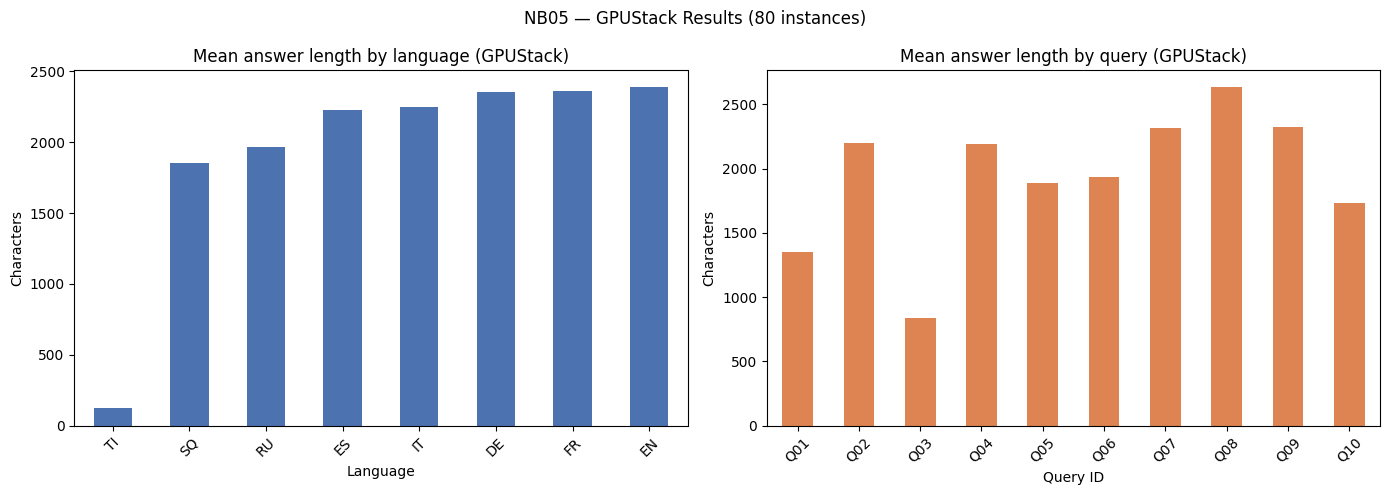

Figure saved.


In [19]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# load GPU results
with open("data/eval/rag_results_gpu.json", encoding="utf-8") as f:
    results_gpu = json.load(f)

df_gpu = pd.DataFrame(results_gpu)
df_gpu["answer_length"] = df_gpu["answer"].str.len()

# plot answer length by language
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_gpu.groupby("language")["answer_length"].mean().sort_values().plot(
    kind="bar", ax=axes[0], color="#4C72B0"
)
axes[0].set_title("Mean answer length by language (GPUStack)")
axes[0].set_xlabel("Language")
axes[0].set_ylabel("Characters")
axes[0].tick_params(axis="x", rotation=45)

df_gpu.groupby("query_id")["answer_length"].mean().plot(
    kind="bar", ax=axes[1], color="#DD8452"
)
axes[1].set_title("Mean answer length by query (GPUStack)")
axes[1].set_xlabel("Query ID")
axes[1].set_ylabel("Characters")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("NB05 — GPUStack Results (80 instances)")
plt.tight_layout()
plt.savefig("report/figures/nb05_gpu_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")